In [1]:
from langgraph.graph import StateGraph,START,END
from typing import  TypedDict

In [36]:
from typing import Optional,NotRequired


class BMIState(TypedDict):
    height_m:float
    weight_kg:float
    bmi:float
    category: Optional[str]

def calculate_BMI(state:BMIState) -> BMIState:
    height=state['height_m']
    weight=state['weight_kg']
    cal_bmi=weight/(height**2)
    state['bmi']=round(cal_bmi,2)
    return state


In [32]:
def label_BMI(state:BMIState) -> BMIState:
    bmi=state['bmi']
    label:str
    if bmi<18:
        label='Underweight'
    elif 18<= bmi<25:
        label='Normal'
    elif 25<= bmi<30:
        label='overweight'
    else:
        label='Obese'
    
    state['category']=label

    return state

In [38]:
graph=StateGraph(BMIState)
# add Node
graph.add_node('calculate_BMI',calculate_BMI)
graph.add_node('bmi_category',label_BMI)
# add Edge
graph.add_edge(START,'calculate_BMI')
graph.add_edge('calculate_BMI','bmi_category')
graph.add_edge('bmi_category',END)

#compile graph
work_flow=graph.compile()


In [39]:
intial_state:BMIState={'weight_kg':83,'height_m':1.73}
final_state = work_flow.invoke(intial_state)

print(final_state)

{'height_m': 1.73, 'weight_kg': 83, 'bmi': 27.73, 'category': 'overweight'}


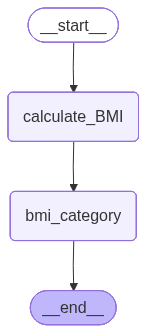

In [33]:
from IPython.display import Image
Image(work_flow.get_graph().draw_mermaid_png())